In [4]:
from torch.optim import AdamW


In [5]:
import json
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import numpy as np

In [8]:
def load_jsonl(path):
    data = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            data.append(json.loads(line))
    return data

train_data = load_jsonl("./train.json")
test_data  = load_jsonl("./test.json")
val_data   = load_jsonl("./validation.json")

print("Train records:", len(train_data))
print("Test records:", len(test_data))
print("Val records:", len(val_data))
print("First example:", train_data[0])


Train records: 3000
Test records: 1500
Val records: 400
First example: {'ID': '2017-En-11484', 'Tweet': "LGBTQ media should inform, inspire, entertain &amp;unite our community. It shouldn't give platform 2 those whose goal is 2 offend us 4 attention", 'anger': True, 'anticipation': False, 'disgust': True, 'fear': False, 'joy': True, 'love': False, 'optimism': False, 'pessimism': False, 'sadness': False, 'surprise': False, 'trust': False}


In [33]:
labels = ['anger','anticipation','disgust','fear','joy','love','optimism',
          'pessimism','sadness','surprise','trust']

label_to_id = {lab: i for i, lab in enumerate(labels)}
num_labels = len(labels)
print(label_to_id)


{'anger': 0, 'anticipation': 1, 'disgust': 2, 'fear': 3, 'joy': 4, 'love': 5, 'optimism': 6, 'pessimism': 7, 'sadness': 8, 'surprise': 9, 'trust': 10}


In [35]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

class TweetDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        item = self.data[idx]


        text = item['Tweet'] 
        y = torch.zeros(num_labels, dtype=torch.float)
        for i, lab in enumerate(labels):
            val = item.get(lab, False)
            if isinstance(val, bool) and val:
                y[i] = 1.0
        enc = tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=128,
            return_tensors='pt'
        )

        enc = {k: v.squeeze(0) for k, v in enc.items()}
        enc['labels'] = y
        return enc


In [ ]:
train_ds = TweetDataset(train_data)
val_ds   = TweetDataset(val_data)
test_ds  = TweetDataset(test_data)
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=16, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=16, shuffle=False)

len(train_ds), len(val_ds), len(test_ds)


(3000, 400, 1500)

In [37]:
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=num_labels,
    problem_type="multi_label_classification"
)
model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)
epochs = 5
total_steps = len(train_loader) * epochs

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [38]:
train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    total_train_loss = 0.0

    for batch in tqdm(train_loader):
        batch = {k: v.to(device) for k, v in batch.items()}
        optimizer.zero_grad()

        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()

        optimizer.step()
        scheduler.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    total_val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            total_val_loss += outputs.loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")



  0%|          | 0/188 [00:00<?, ?it/s]

Epoch 1/5 - Train Loss: 0.4481 | Val Loss: 0.3628


  0%|          | 0/188 [00:00<?, ?it/s]

Epoch 2/5 - Train Loss: 0.3362 | Val Loss: 0.3314


  0%|          | 0/188 [00:00<?, ?it/s]

Epoch 3/5 - Train Loss: 0.2912 | Val Loss: 0.3269


  0%|          | 0/188 [00:00<?, ?it/s]

Epoch 4/5 - Train Loss: 0.2654 | Val Loss: 0.3233


  0%|          | 0/188 [00:00<?, ?it/s]

Epoch 5/5 - Train Loss: 0.2519 | Val Loss: 0.3232


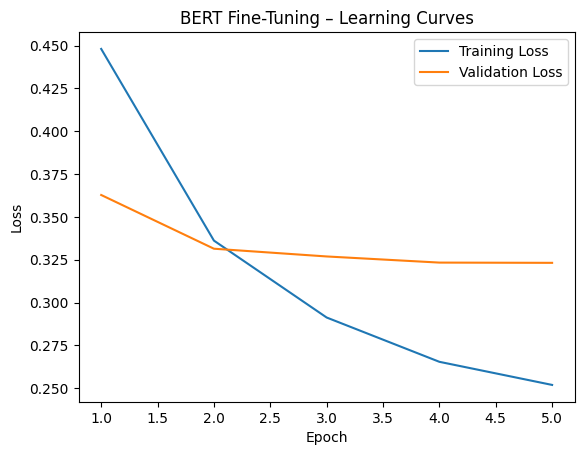

In [39]:
plt.plot(range(1, epochs+1), train_losses, label="Training Loss")
plt.plot(range(1, epochs+1), val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BERT Fine-Tuning – Learning Curves")
plt.legend()
plt.show()


In [41]:
def get_label_vector(item):
    y = torch.zeros(num_labels, dtype=torch.float)
    for i, lab in enumerate(labels):
        val = item.get(lab, False)
        if isinstance(val, bool) and val:
            y[i] = 1.0
    return y

In [42]:
from torch.nn.functional import sigmoid

def exact_match_accuracy():
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for item in test_data:
            text = item['Tweet']
            true_vec = get_label_vector(item)
            
            enc = tokenizer(
                text,
                truncation=True,
                padding='max_length',
                max_length=128,
                return_tensors='pt'
            ).to(device)
            
            outputs = model(**enc)
            logits = outputs.logits.squeeze(0)
            probs = sigmoid(logits)
            preds = (probs > 0.5).cpu().float()
            
            if torch.equal(preds, true_vec):
                correct += 1
                
            total += 1

    return correct / total

exact_match_acc = exact_match_accuracy()
print("Exact Match Test Accuracy:", exact_match_acc)


Exact Match Test Accuracy: 0.268


In [43]:
def one_label_accuracy():
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for item in test_data:
            text = item['Tweet']
            true_vec = get_label_vector(item)
            
            enc = tokenizer(
                text,
                truncation=True,
                padding='max_length',
                max_length=128,
                return_tensors='pt'
            ).to(device)
            
            outputs = model(**enc)
            logits = outputs.logits.squeeze(0)
            probs = sigmoid(logits)
            preds = (probs > 0.5).cpu().float()
            if (preds * true_vec).sum() > 0:
                correct += 1

            total += 1

    return correct / total

one_label_acc = one_label_accuracy()
print("One-Label-Match Test Accuracy:", one_label_acc)


One-Label-Match Test Accuracy: 0.85
